Importing libraries 

In [5]:
from sqlalchemy import create_engine, inspect
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

Data Loading and Overview \
Data consists of different characteristics of websites and a label where "1" indicates a phishing website while "0" indicates a legitimate website

In [8]:
engine = create_engine("sqlite:///data/phishing.db")
inspector = inspect(engine)
data = inspector.get_table_names()
df = pd.read_sql_table("phishing_data", engine)

In [10]:
print(f"Phishing dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Phishing dataset has 10500 rows and 16 columns


In [12]:
df.head()

,Unnamed: 0,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,Industry,HostingProvider,DomainAgeMonths,label
0,0,NaN,9965,0,0,2,1,48,172,170,1,1,Fashion,DreamHost,98,0
1,1,769.0,9507,0,0,0,4,25,55,78,1,1,Fashion,AWS,31,1
2,2,720.0,2550,0,0,0,2,-31,94,13,0,1,Education,Google Cloud,26,1
3,3,198.0,869,0,0,0,0,0,0,2,0,0,Unknown,DreamHost,2,1
4,4,972.0,2807,0,0,0,2,6,83,51,0,1,Education,GoDaddy,43,1


Notable Observations from the surface \
2355 samples (About ~22%)  are missing "LineOfCode" values \
377 samples (About ~3.6%) contain invalid negative values for "NoOfImage" \
1446 samples (About ~13%) come from unknown industries \
1177 samples (About ~11.2%) come from unknown hosting providers \
Number of Phishing websites against number of Legitimate websites are relatively close indicating a balanced dataset

In [15]:
df.dtypes

Unnamed: 0             int64
LineOfCode           float64
LargestLineLength      int64
NoOfURLRedirect        int64
NoOfSelfRedirect       int64
NoOfPopup              int64
NoOfiFrame             int64
NoOfImage              int64
NoOfSelfRef            int64
NoOfExternalRef        int64
Robots                 int64
IsResponsive           int64
Industry              object
HostingProvider       object
DomainAgeMonths        int64
label                  int64
dtype: object

In [17]:
df.describe()

,Unnamed: 0,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,DomainAgeMonths,label
count,10500.000000,8145.000000,1.050000e+04,10500.000000,10500.000000,10500.000000,10500.000000,1.050000e+04,10500.00000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000
mean,5249.500000,1376.952363,1.119796e+04,0.136762,0.038476,0.227524,1.668381,3.252675e+02,68.54219,51.152476,0.262952,0.623619,33.170190,0.550381
std,3031.233247,5751.557001,9.416898e+04,0.343612,0.192352,5.700292,5.016302,3.089686e+04,316.67927,204.902781,0.440258,0.484500,32.698117,0.497479
min,0.000000,2.000000,2.200000e+01,0.000000,0.000000,0.000000,0.000000,-3.500000e+01,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2624.750000,88.000000,1.807500e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,1.000000,0.000000,0.000000,5.000000,0.000000
50%,5249.500000,620.000000,1.087500e+03,0.000000,0.000000,0.000000,0.000000,5.000000e+00,12.00000,10.000000,0.000000,1.000000,24.000000,1.000000
75%,7874.250000,1452.000000,8.047000e+03,0.000000,0.000000,0.000000,1.000000,2.500000e+01,87.00000,55.000000,1.000000,1.000000,52.000000,1.000000
max,10499.000000,418650.000000,4.336498e+06,1.000000,1.000000,564.000000,131.000000,3.166000e+06,26596.00000,12353.000000,1.000000,1.000000,120.000000,1.000000


Data looks relatively normal with the exception of the negative minimum of NoOfImage and the count of LineOfCode being lower than the size of the dataset

In [20]:
df.isna().sum()

Unnamed: 0              0
LineOfCode           2355
LargestLineLength       0
NoOfURLRedirect         0
NoOfSelfRedirect        0
NoOfPopup               0
NoOfiFrame              0
NoOfImage               0
NoOfSelfRef             0
NoOfExternalRef         0
Robots                  0
IsResponsive            0
Industry                0
HostingProvider         0
DomainAgeMonths         0
label                   0
dtype: int64

Can be seen that "LineOfCode" contains many null values

In [23]:
print(f" Number of Phishing websites : {(df["label"]==1).sum()}")
print(f" Number of legitimate websites : {(df["label"]==0).sum()}")

 Number of Phishing websites : 5779
 Number of legitimate websites : 4721


In [25]:
print(f"Number of unknown industries in dataset : {(df["Industry"]=="Unknown").sum()}")
print(f"Number of unknown HostingProviders in dataset : {(df["HostingProvider"]=="Unknown Provider").sum()}")

Number of unknown industries in dataset : 1446
Number of unknown HostingProviders in dataset : 1177


Number of phishing websites and legitimate websites in the dataset are relatively balanced


Data preparation \
Notable Change:  \
Column "Unnamed: 0" is dropped as it does not have any useful information \
Replace all negative values in NoOfImage to be 0 as it is impossible to have negative images, preventing it from impacting the models performance \
Missing values in LineOfCode are imputed later on in the preprocessing stage  \
Normalise all categorical features to prevent duplicate categories of the same category during one hot encoding (there are two ecommerce categories in "Industry")

In [29]:
df = df.drop(columns=["Unnamed: 0"])

In [31]:
df.loc[df["NoOfImage"] < 0, "NoOfImage"] = 0

Zeroing out all negative values in NoOfImage

In [34]:
Categorical_cols = ["Industry", "HostingProvider"]
for cate in Categorical_cols:
    df[cate] = df[cate].astype(str).str.strip().str.lower()

Data Exploration
Dataset contain both categorical and numerical features  \
Numerical features include LineOfCode, LargestLineLength, NoOfURLRedirect, NoOfSelfRedirect, NoOfPopup, NoOfiFrame, NoOfImage, NoOfSelfRef	NoOfExternalRef, Robots, IsResponsive, DomainAgeMonths   \
Categorical features include Industry, HostingProvider

Key Findings: \
Domain Age for phishing websites are on average much higher than legitimate websites. \
All samples with null values for LineOfCode are legitimate websites indicating a potential strong indicator \
There are a few samples with the same features but opposing label indicators \
There are a great number of outliers in the numerical features with very high values \
NoOfExternalRef, IsResponsive and Robots.txt show a potential strong linear relationship with the phishing indicator (more = increased likelihood of phishing)


In [37]:
Numerical_cols = ['LineOfCode', 'LargestLineLength', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'NoOfPopup', 'NoOfiFrame', 'NoOfImage',
       'NoOfSelfRef', 'NoOfExternalRef', 'Robots', 'IsResponsive', 'DomainAgeMonths']

table = []
for feature in Numerical_cols:
    stat = df.groupby("label")[feature].agg(["mean","median"])
    table.append(stat)
    stat["Feature"] = feature
table_pd = pd.concat(table, ignore_index=False)
table_pd = table_pd.reset_index()
Table = (table_pd.reset_index().pivot(index="Feature",
        columns="label",
        values=["mean", "median"]))
Table.columns = [
    "Mean (Legitimate)",
    "Mean (Phishing)",
    "Median (Legitimate)",
    "Median (Phishing)",
]
Table

,Mean (Legitimate),Mean (Phishing),Median (Legitimate),Median (Phishing)
Feature,,,,
DomainAgeMonths,21.126880,43.008652,8.0,39.0
IsResponsive,0.446727,0.768126,0.0,1.0
LargestLineLength,13556.223681,9271.445406,273.0,2333.0
LineOfCode,542.850803,1718.444714,37.0,888.0
NoOfExternalRef,22.109299,74.878526,1.0,31.0
NoOfImage,11.167337,584.015401,0.0,18.0
NoOfPopup,0.080280,0.347811,0.0,0.0
NoOfSelfRedirect,0.046388,0.032012,0.0,0.0
NoOfSelfRef,28.459013,101.287074,0.0,58.0


DomainAgeMonths, IsResponsive, LineOfCode, NoOfExternalRef, NoOfImage, NoOfPopup, NoOfSelfRef, NoOfiFrame and Robots seem to be significant in determining whether a website is a phishing or legitimate website. \
However LineOfCode, NoOfImage, NoOfiFrame have a much larger means than their respective medians indicating that they are heavily right-skewed, this might also mean a large number of outliers with very high values.

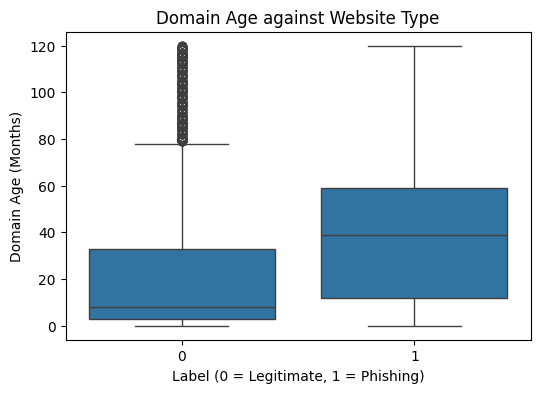

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='DomainAgeMonths', data=df)
plt.title("Domain Age against Website Type")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Domain Age (Months)")
plt.show()

Interesting observation, we expect the older the website the more likely it is to be legitimate, however the dataset shows the opposite where the domain age mean of phishing websites (43) are substantially higher than legitimate websites (21) \
This might be due to older websites being easier to compromise 

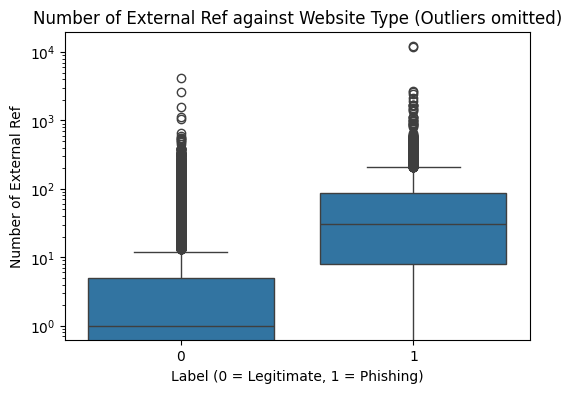

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='NoOfExternalRef', data=df, showfliers = True)
plt.title("Number of External Ref against Website Type (Outliers omitted)")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.yscale("log")
plt.ylabel("Number of External Ref")
plt.show()


Mean number of external ref for legitimate websites (75) is substantially bigger than for phishing websites (22)  \
This might be due to the need for phishing websites to use external tools for malicious purposes

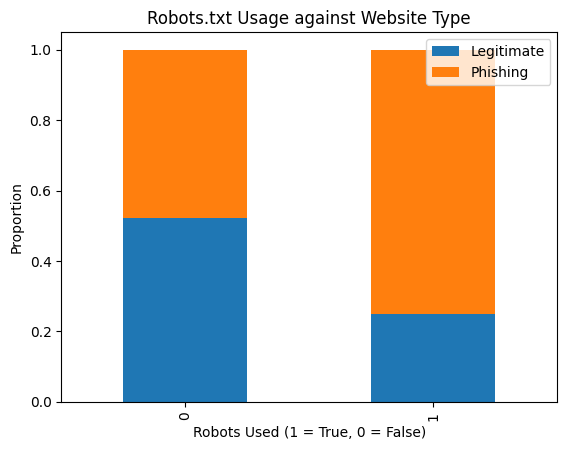

In [46]:
prop = pd.crosstab(df["Robots"], df["label"], normalize="index")

prop.plot(kind="bar", stacked=True)
plt.legend(["Legitimate", "Phishing"])
plt.title("Robots.txt Usage against Website Type")
plt.ylabel("Proportion")
plt.xlabel("Robots Used (1 = True, 0 = False)")
plt.show()

Proportion of phishing websites that use Robots.txt is significantly greater than legitimate websites \
This is expected as phishing websites need to evade security tools

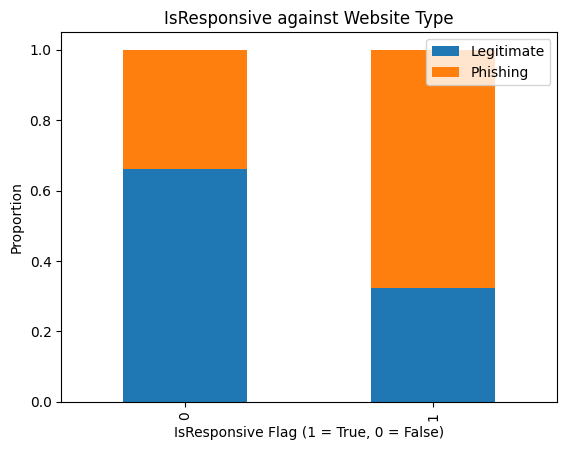

In [49]:
prop = pd.crosstab(df["IsResponsive"], df["label"], normalize="index")

prop.plot(kind="bar", stacked=True)
plt.legend(["Legitimate", "Phishing"])
plt.title("IsResponsive against Website Type")
plt.ylabel("Proportion")
plt.xlabel("IsResponsive Flag (1 = True, 0 = False)")
plt.show()

Proportion of phishing websites that IsResponsive is significantly greater than legitimate websites \
This might indicate phishing websites are more adapted to other devices such as phone where users are more susceptible to fall to malicious traps due to a smaller interface

In [52]:
stats = df.groupby("HostingProvider")["label"].agg(count = "count", phishing_rate = "mean").sort_values(["phishing_rate"], ascending=False)
label_counts = pd.crosstab(df["HostingProvider"],df["label"])
label_counts.columns = [f"label_{s}_count" for s in label_counts.columns]
stats = stats.join(label_counts)
stats

,count,phishing_rate,label_0_count,label_1_count
HostingProvider,,,,
google cloud,763,0.792923,158,605
azure,746,0.784182,161,585
aws,754,0.761273,180,574
bluehost,908,0.753304,224,684
hostgator,885,0.750282,221,664
godaddy,940,0.687234,294,646
dreamhost,611,0.474632,321,290
namecheap,666,0.466967,355,311
hostinger,701,0.459344,379,322


Phishing_rate is described as the number of phishing websites over the total number of websites for that feature  \
Some Hosting Providers have a much high phishing_rate than others for example GoogleCloud, Azure, Bluehost, HostGator all have a phishing_rate higher than 0.75  \
Other Hosting Providers have a much smaller phishing rate such as InfinityFree and Freehostia  \
This might be indicative of the security level of hosting providers or the preference of those who create phishing websites

In [55]:
stats = df.groupby("Industry")["label"].agg(count = "count", phishing_rate = "mean").sort_values(["phishing_rate"], ascending=False)
label_counts = pd.crosstab(df["Industry"],df["label"])
label_counts.columns = [f"label_{s}_count" for s in label_counts.columns]
stats = stats.join(label_counts)
stats

,count,phishing_rate,label_0_count,label_1_count
Industry,,,,
food,296,0.706081,87,209
non-profit,1580,0.686709,495,1085
government,543,0.661142,184,359
fashion,839,0.629321,311,528
manufacturing,658,0.621581,249,409
healthcare,423,0.617021,162,261
education,1486,0.549125,670,816
unknown,1446,0.468188,769,677
ecommerce,2965,0.452277,1624,1341


Some Industries have a much higher phishing_rate such as Food, Non-profit and government \
Other Indstries have a much smaller phishing_rate such as Banking and eCommerce \
This might indicate a preference for phishing websites  \
However, considering the inbalanced sample sizes for the different industries, this should not be used as a sole indicator.

In [58]:
print((df.loc[df["LineOfCode"].isna(), "label"]==0).mean())

1.0


All 2335 samples which have null values for the LineOfCode are legitimate websites, it may be big indicator of whether a webite is a phishing website or not \
However it might also indicate a fault in the way it its collected for legitimate websites.

In [61]:
feature_cols = [cols for cols in df.columns if cols != "label"]
duplicated_with_different_labels = df[df.duplicated(subset=feature_cols, keep = False)].groupby(feature_cols)["label"].nunique()
s = (duplicated_with_different_labels>1).sum()
print(f"There are {s} samples with the exact same features but with different label indicators")

There are 42 samples with the exact same features but with different label indicators


This will confuse the model and lead to a loss in effectiveness , however considering its small sample size compared to the dataset size, its impact is limited